# 입력 feature 선택 및 OO모델 학습 및 검증

## 1. 데이터 준비

In [1]:
from __future__ import annotations

import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
import joblib

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

SEED = 42
TEST_SIZE = 0.2
MODEL_NAME = "logistic_regression"
LABEL_MAPPING = {"human": 0, "macro": 1}

# 데이터 경로 설정
ROOT = Path.cwd()

if ROOT.name != "model_experiment":
    raise Exception("데이터를 찾기 위해 작업 디렉토리 확인 필요")

CONFIG_PATH = Path("../../configs/feature_config.yaml")
DATA_DIR = Path("../../data/behavior")
MODEL_DIR = Path("../model_joblib") / MODEL_NAME

print("ROOT:", ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)


ROOT: c:\Users\SSAFY\Desktop\ws\free\S14P31A203\services\ai\train\model_experiment
CONFIG_PATH: ..\..\configs\feature_config.yaml
DATA_DIR: ..\..\data\behavior
MODEL_DIR: ..\model_joblib\logistic_regression


In [3]:
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_NAME_KR = feature_config["names_ko"]
FEATURE_INPUTS = feature_config["input_features_chan"]


(comment)

string 전처리 feature -> 후속으로는 바로 받아오게 하는 것이 필요

raw: 
 - pre_click_mouse_path_pattern_300ms
 - pre_click_mouse_path_pattern_500ms

In [4]:
def load_data(data_dir: Path) -> pd.DataFrame:
    """데이터 로드

    Args:
        data_dir (Path): 데이터 디렉토리 경로
    Returns:
        pd.DataFrame: 행동 데이터프레임
    """

    rows: list[dict] = []
    
    for path in sorted(data_dir.glob("trial_*.json")):

        data = json.loads(path.read_text(encoding="utf-8"))
        label = data.get("label", None)

        if(label is None):
            continue

        feature = data.get("metrics", {})

        row = {
            "label": label,
        }

        if isinstance(feature, dict):
            row.update(feature)
        
        rows.append(row)

    df = pd.DataFrame(rows)

    return df

df = load_data(DATA_DIR)

display(df.head())

,label,time_to_first_click_ms,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,inter_click_interval_ms,click_sequence_consistency_score,click_position_repeat_rate,click_offset_from_element_center_px,click_offset_variance_px,double_click_rate,misclick_rate,reclick_rate,pre_click_mousemove_count,pre_click_hover_time_ms,pre_click_scroll_flag,immediate_post_render_click_rate,mouse_total_travel_distance_px,mouse_avg_speed_px_per_ms,mouse_max_speed_px_per_ms,mouse_speed_change_mean,mouse_acceleration_mean,mouse_jerk_mean,mouse_path_straightness_score,mouse_path_curvature_mean,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,pre_click_mouse_path_pattern_300ms,pre_click_mouse_path_pattern_500ms,inter_element_move_interval_std_ms,edge_or_fixed_point_visit_rate,time_to_first_keydown_ms,inter_key_interval_ms_mean,inter_key_interval_ms_std,keydown_to_keyup_ms_mean,typing_total_duration_ms,typing_speed_cps,backspace_rate,correction_count,paste_flag,focus_to_submit_ms
0,macro,1523.0,386.880000,386.880000,166.350000,1.000000,0.0,0.930801,0.022615,0.800000,0.000000,0.000000,9.800000,34.080000,0.0,0.8,1736.623385,0.793450,32.367655,7.323334,0.473873,0.064371,0.450931,0.282933,4,0,86.850000,6,9.137844,1147.5px | straight 0.49,1334.3px | straight 0.33,77.765593,0.0,35.3,24.716667,8.346140,19.471429,148.3,47.201618,0.0,0,0,289.6
1,human,851.7,1513.637500,1513.637500,700.800000,0.875000,0.0,28.493302,646.669910,0.444444,0.111111,0.111111,27.444444,246.944444,0.0,0.0,2828.306989,0.437927,10.561944,0.445123,0.052016,0.004934,0.358283,0.206629,58,0,210.584000,20,46.296296,40.9px | straight 0.93,814.6px | straight 0.97,694.574215,0.0,558.8,192.150000,131.387845,117.814286,1152.9,6.071645,0.0,0,0,2887.7
2,human,951.6,1510.433333,1510.433333,836.316667,0.833333,0.0,26.679236,122.389226,0.285714,0.142857,0.000000,33.000000,220.442857,0.0,0.0,1969.649553,0.329936,6.833317,0.267882,0.031645,0.003265,0.449383,0.248568,74,0,199.658333,12,50.587959,133.3px | straight 0.97,702.2px | straight 0.98,704.293103,0.0,622.1,153.960000,56.480779,127.083333,769.8,7.794232,0.0,0,0,2363.3
3,human,1731.0,1456.900000,1456.900000,951.050000,1.000000,0.0,45.429430,1404.299006,0.200000,0.000000,0.000000,33.400000,207.200000,0.0,0.0,1939.123226,0.350300,5.180723,0.306412,0.036340,0.003624,0.451466,0.138800,35,0,193.380000,9,42.452489,81.9px | straight 0.94,593.8px | straight 0.99,674.567448,0.0,523.9,161.580000,87.159358,147.133333,807.9,7.426662,0.0,0,0,2125.2
4,human,1533.5,1529.080000,1529.080000,868.060000,0.800000,0.0,29.553804,374.657158,0.333333,0.166667,0.000000,29.500000,178.900000,0.0,0.0,2085.415223,0.355025,4.651163,0.269461,0.032168,0.003403,0.428887,0.206689,47,0,175.150000,13,43.752128,92.9px | straight 0.98,626.0px | straight 0.99,726.495620,0.0,468.5,156.800000,51.045117,129.183333,784.0,7.653061,0.0,0,0,2587.7


## 2. 데이터 전처리

In [5]:
def add_pre_click_path_features(df: pd.DataFrame) -> None:
    """pre_click_mouse_path 문자열 패턴에서 거리와 직선성을 추출하여 feature로 추가
    
    Args:
        df (pd.DataFrame): 행동 데이터프레임
    """

    for sec in [300, 500]:
        col = f"pre_click_mouse_path_pattern_{sec}ms"

        parts = (
            df[col]
            .fillna("")
            .astype(str)
            .str.split("|", n=1, expand=True)
        )

        distance_text = (
            parts[0]
            .str.replace("px", "", regex=False)
            .str.strip()
        )

        straightness_text = (
            parts[1]
            .str.replace("straight", "", regex=False)
            .str.strip()
        )

        distance_col = f"pre_click_path_{sec}ms_total_distance_px"
        straightness_col = f"pre_click_path_{sec}ms_straightness"

        insert_idx = df.columns.get_loc(col)

        distance_value = pd.to_numeric(distance_text, errors="coerce")
        straightness_value = pd.to_numeric(straightness_text, errors="coerce")

        df.drop(columns=[col], inplace=True)

        df.insert(insert_idx, distance_col, distance_value)
        df.insert(insert_idx + 1, straightness_col, straightness_value)

add_pre_click_path_features(df)
display(df.head())

,label,time_to_first_click_ms,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,inter_click_interval_ms,click_sequence_consistency_score,click_position_repeat_rate,click_offset_from_element_center_px,click_offset_variance_px,double_click_rate,misclick_rate,reclick_rate,pre_click_mousemove_count,pre_click_hover_time_ms,pre_click_scroll_flag,immediate_post_render_click_rate,mouse_total_travel_distance_px,mouse_avg_speed_px_per_ms,mouse_max_speed_px_per_ms,mouse_speed_change_mean,mouse_acceleration_mean,mouse_jerk_mean,mouse_path_straightness_score,mouse_path_curvature_mean,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,pre_click_path_300ms_total_distance_px,pre_click_path_300ms_straightness,pre_click_path_500ms_total_distance_px,pre_click_path_500ms_straightness,inter_element_move_interval_std_ms,edge_or_fixed_point_visit_rate,time_to_first_keydown_ms,inter_key_interval_ms_mean,inter_key_interval_ms_std,keydown_to_keyup_ms_mean,typing_total_duration_ms,typing_speed_cps,backspace_rate,correction_count,paste_flag,focus_to_submit_ms
0,macro,1523.0,386.880000,386.880000,166.350000,1.000000,0.0,0.930801,0.022615,0.800000,0.000000,0.000000,9.800000,34.080000,0.0,0.8,1736.623385,0.793450,32.367655,7.323334,0.473873,0.064371,0.450931,0.282933,4,0,86.850000,6,9.137844,1147.5,0.49,1334.3,0.33,77.765593,0.0,35.3,24.716667,8.346140,19.471429,148.3,47.201618,0.0,0,0,289.6
1,human,851.7,1513.637500,1513.637500,700.800000,0.875000,0.0,28.493302,646.669910,0.444444,0.111111,0.111111,27.444444,246.944444,0.0,0.0,2828.306989,0.437927,10.561944,0.445123,0.052016,0.004934,0.358283,0.206629,58,0,210.584000,20,46.296296,40.9,0.93,814.6,0.97,694.574215,0.0,558.8,192.150000,131.387845,117.814286,1152.9,6.071645,0.0,0,0,2887.7
2,human,951.6,1510.433333,1510.433333,836.316667,0.833333,0.0,26.679236,122.389226,0.285714,0.142857,0.000000,33.000000,220.442857,0.0,0.0,1969.649553,0.329936,6.833317,0.267882,0.031645,0.003265,0.449383,0.248568,74,0,199.658333,12,50.587959,133.3,0.97,702.2,0.98,704.293103,0.0,622.1,153.960000,56.480779,127.083333,769.8,7.794232,0.0,0,0,2363.3
3,human,1731.0,1456.900000,1456.900000,951.050000,1.000000,0.0,45.429430,1404.299006,0.200000,0.000000,0.000000,33.400000,207.200000,0.0,0.0,1939.123226,0.350300,5.180723,0.306412,0.036340,0.003624,0.451466,0.138800,35,0,193.380000,9,42.452489,81.9,0.94,593.8,0.99,674.567448,0.0,523.9,161.580000,87.159358,147.133333,807.9,7.426662,0.0,0,0,2125.2
4,human,1533.5,1529.080000,1529.080000,868.060000,0.800000,0.0,29.553804,374.657158,0.333333,0.166667,0.000000,29.500000,178.900000,0.0,0.0,2085.415223,0.355025,4.651163,0.269461,0.032168,0.003403,0.428887,0.206689,47,0,175.150000,13,43.752128,92.9,0.98,626.0,0.99,726.495620,0.0,468.5,156.800000,51.045117,129.183333,784.0,7.653061,0.0,0,0,2587.7


In [6]:
def filter_features(df: pd.DataFrame) -> pd.DataFrame:
    """데이터 로드

    Args:
        df (pd.DataFrame): 입력 데이터프레임
    Returns:
        pd.DataFrame: 필터링된 데이터프레임 (실제 입력 features)
    """

    for col in df.columns:
        if col not in FEATURE_INPUTS and col != "label":
            df.drop(columns=[col], inplace=True)


    return df

df = filter_features(df)
display(df.head())

,label,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,inter_click_interval_ms,click_offset_from_element_center_px,pre_click_mousemove_count,mouse_direction_change_count,mouse_stop_segment_count,mousemove_event_rate,pre_click_path_300ms_total_distance_px,pre_click_path_500ms_total_distance_px
0,macro,386.880000,386.880000,166.350000,0.930801,9.800000,4,6,9.137844,1147.5,1334.3
1,human,1513.637500,1513.637500,700.800000,28.493302,27.444444,58,20,46.296296,40.9,814.6
2,human,1510.433333,1510.433333,836.316667,26.679236,33.000000,74,12,50.587959,133.3,702.2
3,human,1456.900000,1456.900000,951.050000,45.429430,33.400000,35,9,42.452489,81.9,593.8
4,human,1529.080000,1529.080000,868.060000,29.553804,29.500000,47,13,43.752128,92.9,626.0


In [7]:
X = (df.drop(columns="label").apply(pd.to_numeric, errors="coerce"))
y = df["label"].map({"human": 0,"macro": 1,}).astype(int)

feature_names = X.columns.tolist()

x_train, x_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

# 클래스 불균형 계산
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())

print("train shape:", x_train.shape, "val shape:", x_val.shape)
print("train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("val class counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("scale_pos_weight:", n_neg / max(n_pos, 1))

train shape: (259, 10) val shape: (65, 10)
train class counts: {np.int64(0): np.int64(128), np.int64(1): np.int64(131)}
val class counts: {np.int64(0): np.int64(32), np.int64(1): np.int64(33)}
scale_pos_weight: 0.9770992366412213


## 3. 모델 준비

In [8]:
from sklearn.linear_model import LogisticRegression

def build_model(seed: int = SEED):
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=seed)),
        ]
    )


def predict_macro_proba(fitted_model, x) -> np.ndarray:
    if hasattr(fitted_model, "predict_proba"):
        return np.asarray(fitted_model.predict_proba(x))[:, 1]
    decision = np.asarray(fitted_model.decision_function(x), dtype=float)
    return 1.0 / (1.0 + np.exp(-decision))


def evaluate_binary(y_true: np.ndarray, proba: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    pred = (proba >= threshold).astype(int)
    out = {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "average_precision": float(average_precision_score(y_true, proba)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, proba))
    except ValueError:
        out["roc_auc"] = float("nan")
    try:
        out["log_loss"] = float(log_loss(y_true, proba, labels=[0, 1]))
    except ValueError:
        out["log_loss"] = float("nan")
    return out


model = build_model(SEED)
model


,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


## 4. 모델 성능 검증 (5-Fold)

In [9]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_result = cross_validate(
    build_model(SEED),
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    [
        {
            "metric": metric.replace("test_", ""),
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
        }
        for metric, values in cv_result.items()
        if metric.startswith("test_")
    ]
).sort_values("metric")

display(cv_summary)


,metric,mean,std
0,accuracy,0.996923,0.006880
5,average_precision,1.000000,0.000000
3,f1,0.997015,0.006675
1,precision,0.994118,0.013153
2,recall,1.000000,0.000000
4,roc_auc,1.000000,0.000000


## 4. 모델 학습 및 평가

In [10]:
model.fit(x_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [11]:
train_proba = predict_macro_proba(model, x_train)
val_proba = predict_macro_proba(model, x_val)

train_metrics = evaluate_binary(y_train, train_proba)
val_metrics = evaluate_binary(y_val, val_proba)

metrics_df = pd.DataFrame(
    [
        {"split": "train", **train_metrics},
        {"split": "validation", **val_metrics},
    ]
)

display(metrics_df)

cm = confusion_matrix(y_val, (val_proba >= 0.5).astype(int), labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["actual_human", "actual_macro"], columns=["pred_human", "pred_macro"])

display(cm_df)

,split,accuracy,precision,recall,f1,average_precision,roc_auc,log_loss
0,train,1.0,1.0,1.0,1.0,1.0,1.0,0.010616
1,validation,1.0,1.0,1.0,1.0,1.0,1.0,0.008091


,pred_human,pred_macro
actual_human,32,0
actual_macro,0,33


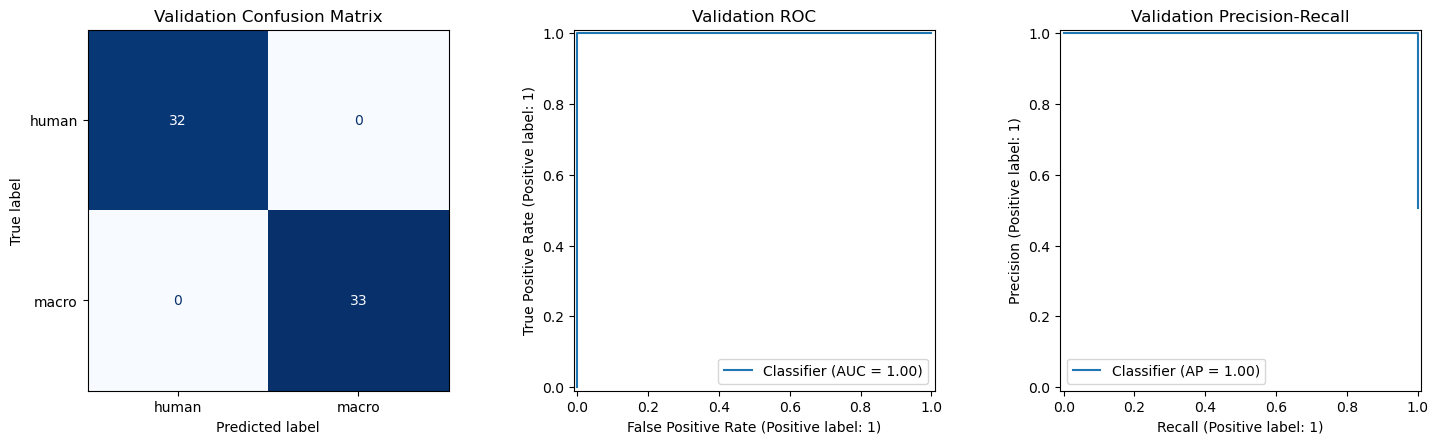

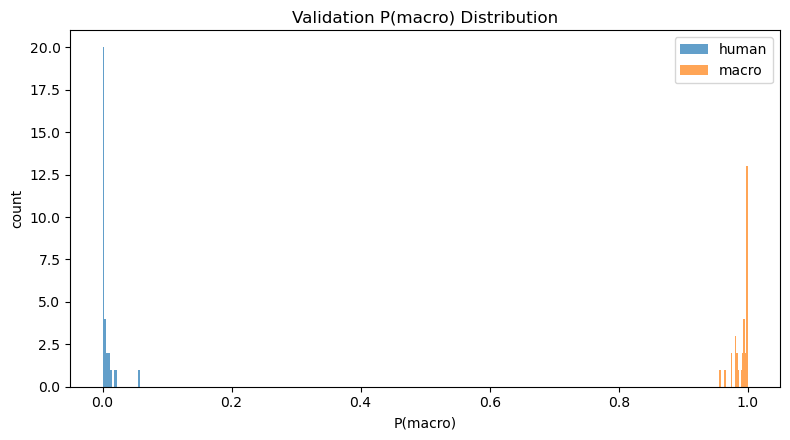

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    (val_proba >= 0.5).astype(int),
    display_labels=["human", "macro"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Validation Confusion Matrix")

RocCurveDisplay.from_predictions(y_val, val_proba, ax=axes[1])
axes[1].set_title("Validation ROC")

PrecisionRecallDisplay.from_predictions(y_val, val_proba, ax=axes[2])
axes[2].set_title("Validation Precision-Recall")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(val_proba[y_val == 0], bins=20, alpha=0.7, label="human")
plt.hist(val_proba[y_val == 1], bins=20, alpha=0.7, label="macro")
plt.title("Validation P(macro) Distribution")
plt.xlabel("P(macro)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# Logistic Regression은 표준화된 계수의 절댓값을 feature 중요도처럼 참고합니다.
clf = model.named_steps["clf"]
coef = clf.coef_.reshape(-1)
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "feature_ko": [FEATURE_NAME_KR.get(f, f) for f in feature_names],
        "importance": np.abs(coef),
        "signed_coef": coef,
    }
).sort_values("importance", ascending=False)
display(importance_df.head(30))


,feature,feature_ko,importance,signed_coef
7,mousemove_event_rate,mousemove 빈도,1.668318,-1.668318
4,pre_click_mousemove_count,클릭 전 이동 수,1.424324,-1.424324
5,mouse_direction_change_count,방향 전환 수,1.287497,-1.287497
3,click_offset_from_element_center_px,중심 오차,0.871247,-0.871247
8,pre_click_path_300ms_total_distance_px,300ms 경로 총거리,0.651129,0.651129
6,mouse_stop_segment_count,정지 구간 수,0.550475,-0.550475
9,pre_click_path_500ms_total_distance_px,500ms 경로 총거리,0.449987,0.449987
2,inter_click_interval_ms,클릭 간격,0.262687,-0.262687
1,time_from_element_clickable_to_click_ms,활성 후 클릭,0.194290,-0.194290
0,time_from_element_visible_to_click_ms,노출 후 클릭,0.194290,-0.194290


## 5. 모델 저장

In [14]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODEL_DIR / "model.joblib"
meta_path = MODEL_DIR / "meta.json"
metrics_path = MODEL_DIR / "metrics.json"

joblib.dump(model, model_path)

meta = {
    "model_name": MODEL_NAME,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "label_mapping": LABEL_MAPPING,
    "feature_config": str(CONFIG_PATH),
    "data_dir": str(DATA_DIR),
    "feature_names": feature_names,
    "n_samples": int(X.shape[0]),
    "n_train": int(x_train.shape[0]),
    "n_validation": int(x_val.shape[0]),
    "test_size": TEST_SIZE,
    "seed": SEED,
}
metrics_payload = {
    "train": train_metrics,
    "validation": val_metrics,
    "cv": cv_summary.to_dict(orient="records"),
    "confusion_matrix_validation": cm.astype(int).tolist(),
}

meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved model:", model_path)
print("saved meta:", meta_path)
print("saved metrics:", metrics_path)


saved model: ..\model_joblib\logistic_regression\model.joblib
saved meta: ..\model_joblib\logistic_regression\meta.json
saved metrics: ..\model_joblib\logistic_regression\metrics.json


In [15]:
# ablation study

from itertools import combinations
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

# =========================
# 설정
# =========================

MAX_REMOVE = 5
N_SPLITS = 5
METRIC = "f1_mean"

# X가 DataFrame이라고 가정
base_features = list(X.columns)

# feature 한글명 매핑이 있으면 사용, 없으면 원본명 사용
try:
    feature_name_map = FEATURE_NAME_KR
except NameError:
    feature_name_map = {feature: feature for feature in base_features}


# =========================
# CV 실행 함수
# =========================

def run_cv_with_features(
    X: pd.DataFrame,
    y,
    features: list[str],
    seed: int = SEED,
    n_splits: int = 5,
) -> dict:
    """주어진 feature set으로 Stratified K-Fold CV 성능 계산"""

    x_sub = X[features].apply(pd.to_numeric, errors="coerce")
    y_arr = np.asarray(y)

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
    }

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )

    cv_result = cross_validate(
        build_model(seed),
        x_sub,
        y_arr,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    result = {
        "n_features": len(features),
        "features": features,
    }

    for metric in scoring:
        values = cv_result[f"test_{metric}"]
        result[f"{metric}_mean"] = float(values.mean())
        result[f"{metric}_std"] = float(values.std(ddof=1))

    return result


# =========================
# 1개 ~ MAX_REMOVE개 제거 조합 평가
# =========================

rows = []

base_result = run_cv_with_features(
    X=X,
    y=y,
    features=base_features,
    seed=SEED,
    n_splits=N_SPLITS,
)

base_score = base_result[METRIC]

rows.append({
    "case": "baseline",
    "n_removed": 0,
    "n_features": len(base_features),
    "removed_features": [],
    "removed_features_ko": [],
    "remain_features": base_features,
    "remain_features_ko": [
        feature_name_map.get(feature, feature)
        for feature in base_features
    ],
    **{k: v for k, v in base_result.items() if k != "features"},
    "delta_metric": 0.0,
})

max_remove = min(MAX_REMOVE, len(base_features) - 1)

for n_remove in range(1, max_remove + 1):
    for removed_tuple in combinations(base_features, n_remove):
        removed_features = list(removed_tuple)

        remain_features = [
            feature for feature in base_features
            if feature not in removed_features
        ]

        result = run_cv_with_features(
            X=X,
            y=y,
            features=remain_features,
            seed=SEED,
            n_splits=N_SPLITS,
        )

        rows.append({
            "case": f"remove_{n_remove}",
            "n_removed": n_remove,
            "n_features": len(remain_features),
            "removed_features": removed_features,
            "removed_features_ko": [
                feature_name_map.get(feature, feature)
                for feature in removed_features
            ],
            "remain_features": remain_features,
            "remain_features_ko": [
                feature_name_map.get(feature, feature)
                for feature in remain_features
            ],
            **{k: v for k, v in result.items() if k != "features"},
            "delta_metric": float(result[METRIC] - base_score),
        })

ablation_df = pd.DataFrame(rows)

ablation_df = (
    ablation_df
    .sort_values(
        [METRIC, "recall_mean", "precision_mean", "n_features"],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)


# =========================
# 출력용 컬럼
# =========================

display_cols = [
    "case",
    "n_removed",
    "n_features",
    "removed_features_ko",
    "f1_mean",
    "f1_std",
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "roc_auc_mean",
    "average_precision_mean",
    "delta_metric",
]


# =========================
# 1. 전체 ablation 상위 결과
# =========================

print("전체 ablation 결과 Top 30")
display(ablation_df[display_cols].head(30))


# =========================
# 2. 제거 개수별 최고 조합
# =========================

best_by_removed = (
    ablation_df
    .sort_values(
        ["n_removed", METRIC, "recall_mean", "precision_mean"],
        ascending=[True, False, False, False],
    )
    .groupby("n_removed")
    .head(1)
    .reset_index(drop=True)
)

print("제거 개수별 최고 조합")
display(best_by_removed[display_cols])


# =========================
# 3. 성능 유지 후보
# =========================

base_f1 = ablation_df.loc[ablation_df["n_removed"] == 0, "f1_mean"].iloc[0]

candidate_df = (
    ablation_df[
        (ablation_df["f1_mean"] >= base_f1 - 0.005) &
        (ablation_df["recall_mean"] >= 0.99)
    ]
    .sort_values(
        ["n_features", "f1_mean", "precision_mean", "recall_mean"],
        ascending=[True, False, False, False],
    )
    .reset_index(drop=True)
)

print("성능 유지 후보, f1 하락 0.005 이내 & recall 0.99 이상")
display(candidate_df[display_cols].head(30))


# =========================
# 4. 최종 후보 feature 확인
# =========================

if not candidate_df.empty:
    best_candidate = candidate_df.iloc[0]

    print("추천 후보")
    print("제거 feature:", best_candidate["removed_features_ko"])
    print("남은 feature:", best_candidate["remain_features_ko"])
    print("feature 수:", best_candidate["n_features"])
    print("f1_mean:", best_candidate["f1_mean"])
    print("precision_mean:", best_candidate["precision_mean"])
    print("recall_mean:", best_candidate["recall_mean"])
    print("roc_auc_mean:", best_candidate["roc_auc_mean"])

    final_candidate_features = best_candidate["remain_features"]
else:
    print("조건을 만족하는 candidate가 없습니다.")
    final_candidate_features = base_features

전체 ablation 결과 Top 30


,case,n_removed,n_features,removed_features_ko,f1_mean,f1_std,accuracy_mean,precision_mean,recall_mean,roc_auc_mean,average_precision_mean,delta_metric
0,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, 클릭 전 이동 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
1,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, 정지 구간 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
2,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, mousemove 빈도]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
3,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, 500ms 경로 총거리]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
4,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, 방향 전환 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
5,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, 정지 구간 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
6,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, mousemove 빈도]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
7,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, 300ms 경로 총거리]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
8,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, 500ms 경로 총거리]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
9,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 방향 전환 수, 정지 구간 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985


제거 개수별 최고 조합


,case,n_removed,n_features,removed_features_ko,f1_mean,f1_std,accuracy_mean,precision_mean,recall_mean,roc_auc_mean,average_precision_mean,delta_metric
0,baseline,0,10,[],0.997015,0.006675,0.996923,0.994118,1.0,1.0,1.0,0.000000
1,remove_1,1,9,[노출 후 클릭],1.000000,0.000000,1.000000,1.000000,1.0,1.0,1.0,0.002985
2,remove_2,2,8,"[노출 후 클릭, 활성 후 클릭]",1.000000,0.000000,1.000000,1.000000,1.0,1.0,1.0,0.002985
3,remove_3,3,7,"[노출 후 클릭, 활성 후 클릭, 클릭 간격]",1.000000,0.000000,1.000000,1.000000,1.0,1.0,1.0,0.002985
4,remove_4,4,6,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차]",1.000000,0.000000,1.000000,1.000000,1.0,1.0,1.0,0.002985
5,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, 클릭 전 이동 수]",1.000000,0.000000,1.000000,1.000000,1.0,1.0,1.0,0.002985


성능 유지 후보, f1 하락 0.005 이내 & recall 0.99 이상


,case,n_removed,n_features,removed_features_ko,f1_mean,f1_std,accuracy_mean,precision_mean,recall_mean,roc_auc_mean,average_precision_mean,delta_metric
0,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, 클릭 전 이동 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
1,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, 정지 구간 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
2,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, mousemove 빈도]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
3,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 중심 오차, 500ms 경로 총거리]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
4,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, 방향 전환 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
5,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, 정지 구간 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
6,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, mousemove 빈도]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
7,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, 300ms 경로 총거리]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
8,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 클릭 전 이동 수, 500ms 경로 총거리]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985
9,remove_5,5,5,"[노출 후 클릭, 활성 후 클릭, 클릭 간격, 방향 전환 수, 정지 구간 수]",1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.002985


추천 후보
제거 feature: ['노출 후 클릭', '활성 후 클릭', '클릭 간격', '중심 오차', '클릭 전 이동 수']
남은 feature: ['방향 전환 수', '정지 구간 수', 'mousemove 빈도', '300ms 경로 총거리', '500ms 경로 총거리']
feature 수: 5
f1_mean: 1.0
precision_mean: 1.0
recall_mean: 1.0
roc_auc_mean: 1.0


## 6. 결과 리포트